In [125]:
import math 
class Value:
    def __init__(self,data, _children=() , _op='' , label=''):
        self.data=data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        out=Value(self.data + other.data , (self,other), '+')

    #chain rule inside add 
        def _backward():
          self.grad += 1.0 * out.grad
          other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    
    def __mul__(self,other):
        out=Value(self.data * other.data ,(self,other), '*')
        
#chain rule inside multiplication
        def _backward():
          self.grad = other.data * out.grad
          other.grad = self.data * out.grad
        out._backward = _backward
      
        return out
       
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
#chain rule inside the tanh function 
        def _backward():
           self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out


a = Value(2.0 , label='a')
b = Value(-3.0 , label='b')
c = Value(10.0 , label='c')
e = a*b; e.label = 'e'
d = e+c ; d.label ='d'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
d

Value(data=4.0)

In [126]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        label_str = getattr(n, 'label', 'no label')
        data_val = getattr(n, 'data', 0.0)
        grad_val = getattr(n, 'grad', 0.0)
        op_str = getattr(n, '_op', '')
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (label_str, data_val, grad_val), shape='record')
        #dot.node(name=uid, label="{ %s | data %.4f  }" % (label_str, data_val), shape='record')
        if op_str:
            dot.node(name=uid + op_str, label=op_str)
            dot.edge(uid + op_str, uid)
    for n1, n2 in edges:
        op_str = getattr(n2, '_op', '')
        dot.edge(str(id(n1)), str(id(n2)) + op_str)
    return dot
    

# def draw_dot(root):
#   dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
#   nodes, edges = trace(root)
#   for n in nodes:
#     uid = str(id(n))
#     # for any value in the graph, create a rectangular ('record') node for it
#     dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
#     if n._op:
#       # if this value is a result of some operation, create an op node for it
#       dot.node(name = uid + n._op, label = n._op)
#       # and connect this node to it
#       dot.edge(uid + n._op, uid)

#   for n1, n2 in edges:
#     # connect n1 to the op node of n2
#     dot.edge(str(id(n1)), str(id(n2)) + n2._op)

#   return dot

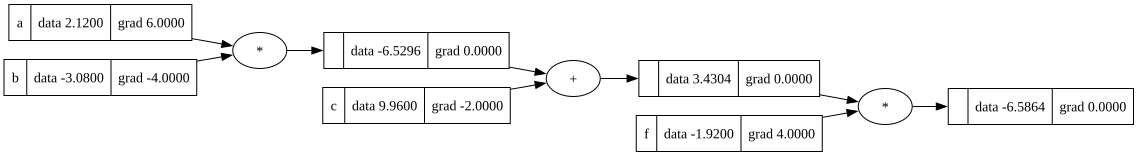

In [53]:
draw_dot(L)

In [48]:
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

In [47]:
dd / de = 1.0
dL/de = -2.0
dL/da = (dL/de) * (de /da)

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (463217038.py, line 1)

In [45]:
c.grad = -2.0
e.grad = -2.0

In [ ]:
dd/dc ? 1.0
 d =c+e 
#(f(x+h)-f(x))/h
((c+h +e ) - (c +e ))/h
(c +h +e -c - e ) /h 
h/h
1.0

WanT : 
dL/dc = (dL/dd) * (dd/dc)

KNOW :

dL/dd
dd/dc


In [ ]:
L = d* f
#dL/dd=? f
#(f(x+h)-f(x))/h
#(d+h)*f - d*f)/h
#(d*f + h*f - d*f )/h
#(h*f)/h
#f

In [40]:
f.grad=4.0
d.grad =-2.0

In [38]:
L.grad = 1.0

In [52]:
a.data += 0.01 *a.grad
b.data += 0.01 *b.grad
c.data += 0.01 *c.grad
f.data += 0.01 *f.grad
e = a*b
d= e+c 

L = d * f; 
print (L.data)


-6.586368000000001


In [37]:
def lol():
  
  h = 0.001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)
  
lol()

-3.9999999999995595


In [11]:
d._op

'+'

In [10]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

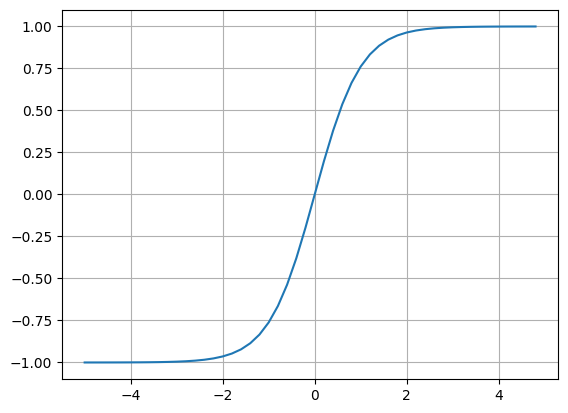

In [58]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

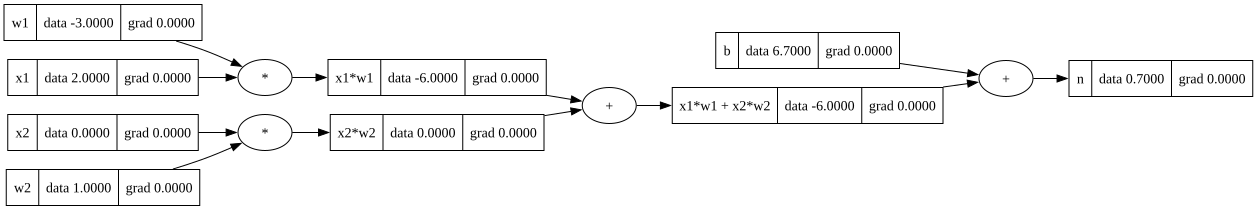

In [59]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.7, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
draw_dot(n)

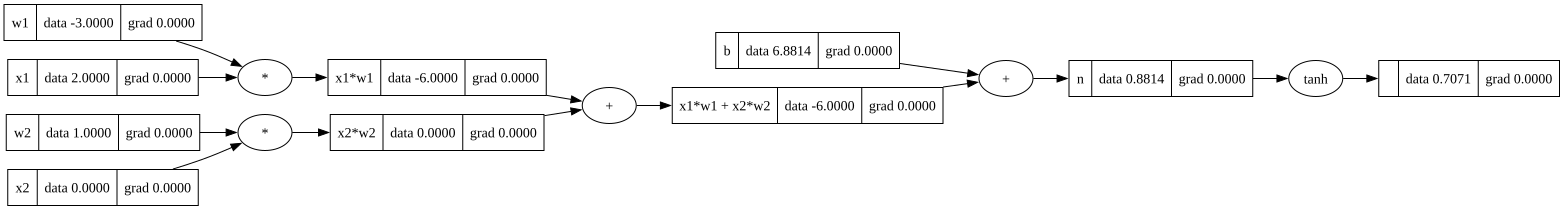

In [86]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh();draw_dot(o)

In [135]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


In [132]:
o.grad=1.0

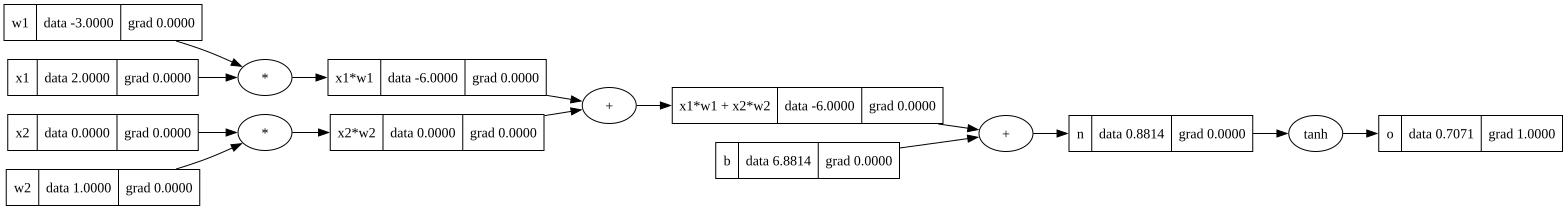

In [133]:
draw_dot(o)

In [134]:
o.grad=1.0

In [130]:
o._backward()

AttributeError: 'Value' object has no attribute '_backward'

In [122]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [123]:
x2.grad=w2.data * x2w2.grad
w2.grad=x2.data * x2w2.grad
#chain rule 

In [77]:
x1w1.grad=0.5
x2w2.grad=0.5

In [75]:
x1w1x2w2.grad=0.5
b.grad=0.5

In [73]:
n.grad =0.5

In [72]:
1- o.data**2

0.4999999999999999

In [ ]:
o = tanh(n)
do / dn = 1 - tanh(n) ** 2
